# Knox Design Analysis Notebook

Spring 2026

EC552 - Computational Synthetic Biology for Engineers

Team Members Names: Alexander Ge

# Notes From James

Depending on number of rules, the rule evaluation algorithm can take 10-30 minutes to run. Rule Evaluations are saved in Neo4j, so you do not
need to rerun the rule evaluation algorithm, call getRuleEvaluation with the name of the evaluation (only 2-5 seconds to retrieve).

Run rule evaluations with:
- ruleEvaluateByGroup
- ruleEvaluateByDesigns


Get rule evaluations with
- getRuleEvaluation


Delete rule evaluations with
- deleteRuleEvaluation


This notebook is to serve as a starting point for doing your analysis.

Feel free to change this notebook in any way you see fit.


# Imports

In [1]:
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn import tree
from sklearn.model_selection import train_test_split

# Knox Request Functions

In [37]:
url = 'http://localhost:8080'

def ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod="sign"):
    """
    API Request to Knox to run Rule Evaluation Algorithm.
    
    Returns:
    metrics (list of pandas DataFrames): purity_metrics, designToRule
    """
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designGroupID=" + groupID + '&' +
                             "rulesGroupID=" + ruleGroupID + '&' +
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def ruleEvaluateByDesigns(evalName, designIDs, ruleGroupID, designScores, labelingMethod="sign"):
    designSpaceIDs = listToStringList(designIDs)
    designScoresStr = listToStringList(designScores) # designScores should be a list of strings, may have to convert floats to strings before running

    # Submit Request
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designSpaceIDs=" + designSpaceIDs + '&' + 
                             "rulesGroupID=" + ruleGroupID + '&' + 
                             "designScores=" + designScoresStr + '&' + 
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def getRuleEvaluation(evalName):
    response = requests.get(url + '/rule/getEvaluation?' + "evaluationName=" + evalName)

    return processRuleEval(response)


def deleteRuleEvaluation(evalName):
    response = requests.delete(url + '/rule?' + "evaluationName=" + evalName)

    if not response.text:
        return f'"{evalName}" Sucessfully Deleted'
    else:
        return response.text
    

def processRuleEval(response):
    # Change to Pandas DataFrame
    json_data = json.loads(response.text)

    purity_metrics_df = pd.DataFrame(json_data["evaluationResults"]).T

    designToRule_df = pd.DataFrame(json_data["designToRule"], index=json_data["designToRule"]["designIDs"])
    cols = designToRule_df.columns.to_list()
    cols.remove("labels")
    cols.remove("scores")
    cols.remove("designIDs")
    cols = ["labels", "scores"] + cols
    designToRule_df = designToRule_df[cols]

    return purity_metrics_df.sort_values("impact"), designToRule_df.sort_values("scores")


def listToStringList(list_input):
    return ",".join(list_input)
    


# Decision Tree Functions

In [5]:
def exampleTree(X, y, **kwargs):
    # Mess around with different parameters
    
    dt_clf = tree.DecisionTreeClassifier(
        splitter=kwargs.get('splitter', 'best'),
        max_depth=kwargs.get('max_depth', None),
        min_samples_split=kwargs.get('min_samples_split', 400),
        min_samples_leaf=kwargs.get('min_samples_leaf', 200),
        max_features=kwargs.get('max_features', None),
        max_leaf_nodes=kwargs.get('max_leaf_nodes', None)
    )
    
    dt_clf = dt_clf.fit(X, y)

    return dt_clf

## Build more Trees, multiclassification and regression


# Design Analysis

### Run RuleEvaluation

In [ ]:
#deleteRuleEvaluation('test')

In [39]:
# Use this for (gnn_predicted_scores.csv) designs already have the attached scores

evalName = 'eval'
groupID = 'three'
ruleGroupID = 'final'

labelingMethod = 'median'

purity_metrics_df, designToRule_df = ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod)

In [81]:
response = requests.get(url + '/rule/getEvaluation?evaluationName=eval')
json_data = json.loads(response.text)
print(json_data.keys())
purity_metrics_df = pd.DataFrame(json_data["evaluationResults"]).T
print(purity_metrics_df.columns.tolist())
print(purity_metrics_df.head())

dict_keys(['evaluationResults', 'designToRule'])
['totalImperfection', 'ruleSpaceID', 'goodDesignsElim', 'impact', 'totalPerfection', 'numIncorrect', 'poorDesignsElim', 'totalDesignsElim', 'poorPerfection', 'poornessPercent', 'numCorrect', 'goodPerfection', 'goodnessPercent', 'poorEliminationPercent']
                   totalImperfection         ruleSpaceID goodDesignsElim  \
final_A1_B2_Rule_I             False  final_A1_B2_Rule_I               0   
final_A1_B2_Rule_F             False  final_A1_B2_Rule_F             758   
final_A1_B2_Rule_B             False  final_A1_B2_Rule_B             168   
final_A1_B2_Rule_A             False  final_A1_B2_Rule_A             758   
final_B2_Rule_R                False     final_B2_Rule_R             222   

                   impact totalPerfection numIncorrect poorDesignsElim  \
final_A1_B2_Rule_I      0            True         1998               0   
final_A1_B2_Rule_F    -18           False         2362             394   
final_A1_B2_Rule_B

In [83]:
# Import true scores
true_scores_df = pd.read_csv("/Users/smile/Downloads/true_scores.csv")
true_scores = [str(s) for s in true_scores_df["weight"].tolist()]

# Design IDs matching your import
designIDs = [f'three_design_({i})' for i in range(1, 3997)]

# Run evaluation with true scores
purity_true, dtr_true = ruleEvaluateByDesigns('eval_true', designIDs, 'final', true_scores, 'median')
print("True scores evaluation complete")

True scores evaluation complete


In [84]:
# Import transformer scores
transformer_scores_df = pd.read_csv("/Users/smile/Downloads/transformer_predicted_scores.csv")
transformer_scores = [str(s) for s in transformer_scores_df["weight"].tolist()]

# Run evaluation with transformer scores
purity_transformer, dtr_transformer = ruleEvaluateByDesigns('eval_transformer', designIDs, 'final', transformer_scores, 'median')
print("Transformer scores evaluation complete")

Transformer scores evaluation complete


In [87]:
# Compare impact scores across all three models
comparison = pd.DataFrame({
    'GNN_impact': purity_metrics_df['impact'].astype(float),
    'True_impact': purity_true['impact'].astype(float),
    'Transformer_impact': purity_transformer['impact'].astype(float)
})

# Correlation between models and true scores
gnn_corr = comparison['GNN_impact'].corr(comparison['True_impact'])
transformer_corr = comparison['Transformer_impact'].corr(comparison['True_impact'])

print(f"GNN vs True impact correlation: {gnn_corr:.4f}")
print(f"Transformer vs True impact correlation: {transformer_corr:.4f}")
print(f"\nThe {'GNN' if gnn_corr > transformer_corr else 'Transformer'} model more closely emulates the true grammar.")

GNN vs True impact correlation: 0.9957
Transformer vs True impact correlation: 0.9614

The GNN model more closely emulates the true grammar.


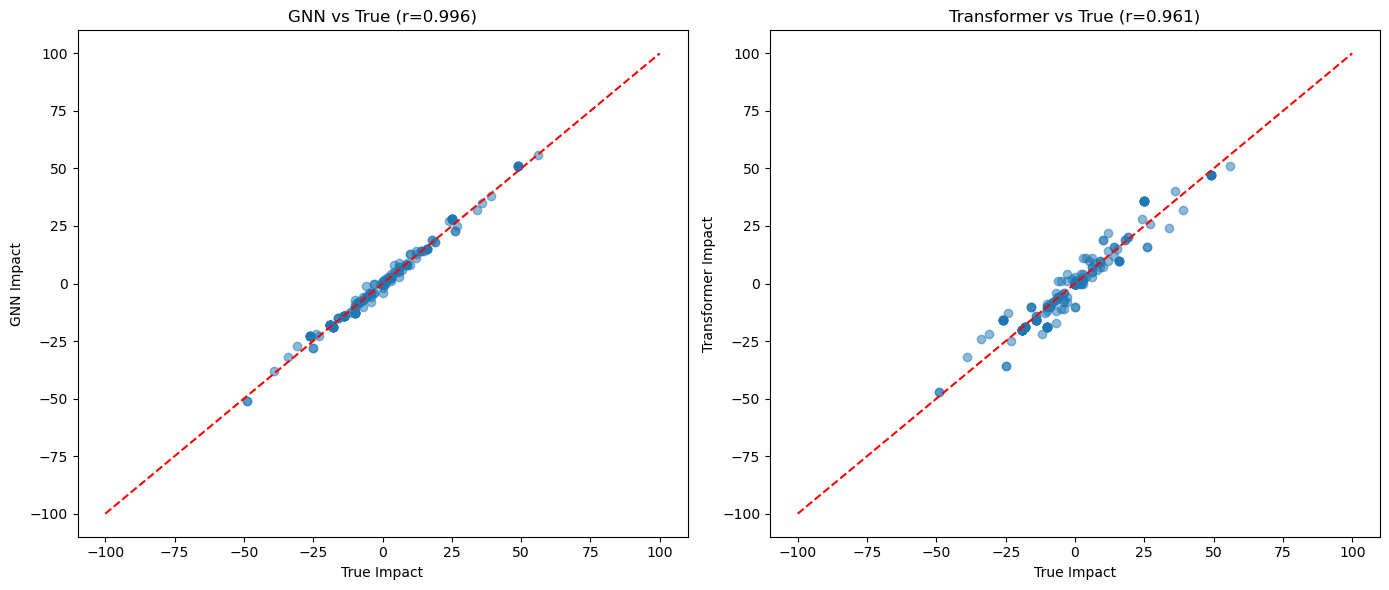

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(comparison['True_impact'], comparison['GNN_impact'], alpha=0.5)
axes[0].set_xlabel('True Impact')
axes[0].set_ylabel('GNN Impact')
axes[0].set_title(f'GNN vs True (r={gnn_corr:.3f})')
axes[0].plot([-100, 100], [-100, 100], 'r--')

axes[1].scatter(comparison['True_impact'], comparison['Transformer_impact'], alpha=0.5)
axes[1].set_xlabel('True Impact')
axes[1].set_ylabel('Transformer Impact')
axes[1].set_title(f'Transformer vs True (r={transformer_corr:.3f})')
axes[1].plot([-100, 100], [-100, 100], 'r--')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### Extra Credit: Which model more closely emulates the true grammar?

We compared the impact scores of each rule across three scoring methods: GNN predicted, Transformer predicted, and True scores. By computing the Pearson correlation between each model's impact scores and the true impact scores, we determined which model's rule evaluations more closely match reality. The model with the higher correlation to the true scores more closely emulates the true grammar, meaning its predictions lead to the same design rules being identified as important.

### View DataFrames

In [41]:
purity_metrics_df

,totalImperfection,ruleSpaceID,goodDesignsElim,impact,totalPerfection,numIncorrect,poorDesignsElim,totalDesignsElim,poorPerfection,poornessPercent,numCorrect,goodPerfection,goodnessPercent,poorEliminationPercent
final_P2_Y_Rule_T,False,final_P2_Y_Rule_T,1757,-51,False,3028,727,2484,False,63,968,False,12,29
final_P2_Rule_M,False,final_P2_Rule_M,1757,-51,False,3028,727,2484,False,63,968,False,12,29
final_PP2_Rule_M,False,final_PP2_Rule_M,1792,-38,False,2774,1016,2808,False,49,1222,False,10,36
final_PH1_Rule_NI,False,final_PH1_Rule_NI,1065,-32,False,2652,411,1476,False,79,1344,False,46,27
final_P1_Rule_M,False,final_P1_Rule_M,1524,-28,False,2562,960,2484,False,51,1434,False,23,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
final_P2_S1_Rule_A,False,final_P2_S1_Rule_A,241,51,False,968,1271,1512,False,36,3028,False,87,84
final_P2_S1_Rule_F,False,final_P2_S1_Rule_F,241,51,False,968,1271,1512,False,36,3028,False,87,84
final_P2_Y_Rule_A,False,final_P2_Y_Rule_A,241,51,False,968,1271,1512,False,36,3028,False,87,84
final_P2_Y_Rule_F,False,final_P2_Y_Rule_F,241,51,False,968,1271,1512,False,36,3028,False,87,84


In [43]:
designToRule_df

,labels,scores,final_A1_B2_Rule_I,final_A1_B2_Rule_F,final_A1_B2_Rule_B,final_A1_B2_Rule_A,final_B2_Rule_R,final_B2_Rule_M,final_A1_B2_Rule_T,final_A1_B2_Rule_O,...,final_A1_S1_Rule_T,final_S1_Rule_NI,final_A1_S1_Rule_I,final_Y_Rule_M,final_P1_S1_Rule_O,final_A1_H1_Rule_F,final_Y_Rule_R,final_A1_S1_Rule_O,final_A1_H1_Rule_I,final_P1_S1_Rule_T
three_design_(181),0,-0.955420,0,1,0,1,0,1,1,0,...,0,1,0,0,0,1,0,1,0,1
three_design_(284),0,-0.948819,0,1,0,1,0,1,1,0,...,0,1,0,0,0,1,0,1,0,1
three_design_(277),0,-0.944792,0,0,0,0,1,0,1,0,...,1,1,0,0,0,0,0,0,0,1
three_design_(122),0,-0.935556,0,0,0,0,0,0,1,0,...,1,1,0,0,0,0,0,0,0,1
three_design_(170),0,-0.930752,0,0,0,0,0,0,1,0,...,1,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
three_design_(3936),1,3.407576,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,0
three_design_(3935),1,3.427389,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,0
three_design_(3929),1,3.437174,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,0
three_design_(3927),1,3.447912,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,0


## Extract Features and Labels from designToRule_df

In [45]:
feature_names = designToRule_df.columns.to_list()[2:]
X = designToRule_df.iloc[:, 2:].to_numpy(dtype=int)
y_labels = designToRule_df["labels"].to_numpy(dtype=int)
y_scores = designToRule_df["scores"].to_numpy(dtype=float)


## Train - Test Split

In [47]:
# Create multi-class labels using quantiles
q1 = np.percentile(y_scores, 25)
q2 = np.percentile(y_scores, 50)
q3 = np.percentile(y_scores, 75)

y_multi = np.array([0 if s < q1 else 1 if s < q2 else 2 if s < q3 else 3 for s in y_scores])

# 70/30 splits
X_train, X_test, y_train_labels, y_test_labels = train_test_split(X, y_labels, test_size=0.3, random_state=42)
_, _, y_train_scores, y_test_scores = train_test_split(X, y_scores, test_size=0.3, random_state=42)
_, _, y_train_multi, y_test_multi = train_test_split(X, y_multi, test_size=0.3, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 2797, Test: 1199


## Build Trees

In [49]:
# Binary Classification Tree
bc_tree = tree.DecisionTreeClassifier(max_depth=4, min_samples_split=50, min_samples_leaf=25)
bc_tree.fit(X_train, y_train_labels)
print(f"Binary Classification Accuracy: {bc_tree.score(X_test, y_test_labels):.4f}")

# Regression Tree
reg_tree = tree.DecisionTreeRegressor(max_depth=4, min_samples_split=50, min_samples_leaf=25)
reg_tree.fit(X_train, y_train_scores)
print(f"Regression Tree R2 Score: {reg_tree.score(X_test, y_test_scores):.4f}")

# Multi-Classification Tree
mc_tree = tree.DecisionTreeClassifier(max_depth=4, min_samples_split=50, min_samples_leaf=25)
mc_tree.fit(X_train, y_train_multi)
print(f"Multi-Class Accuracy: {mc_tree.score(X_test, y_test_multi):.4f}")

Binary Classification Accuracy: 0.8607
Regression Tree R2 Score: 0.5981
Multi-Class Accuracy: 0.6247


## Plot Trees

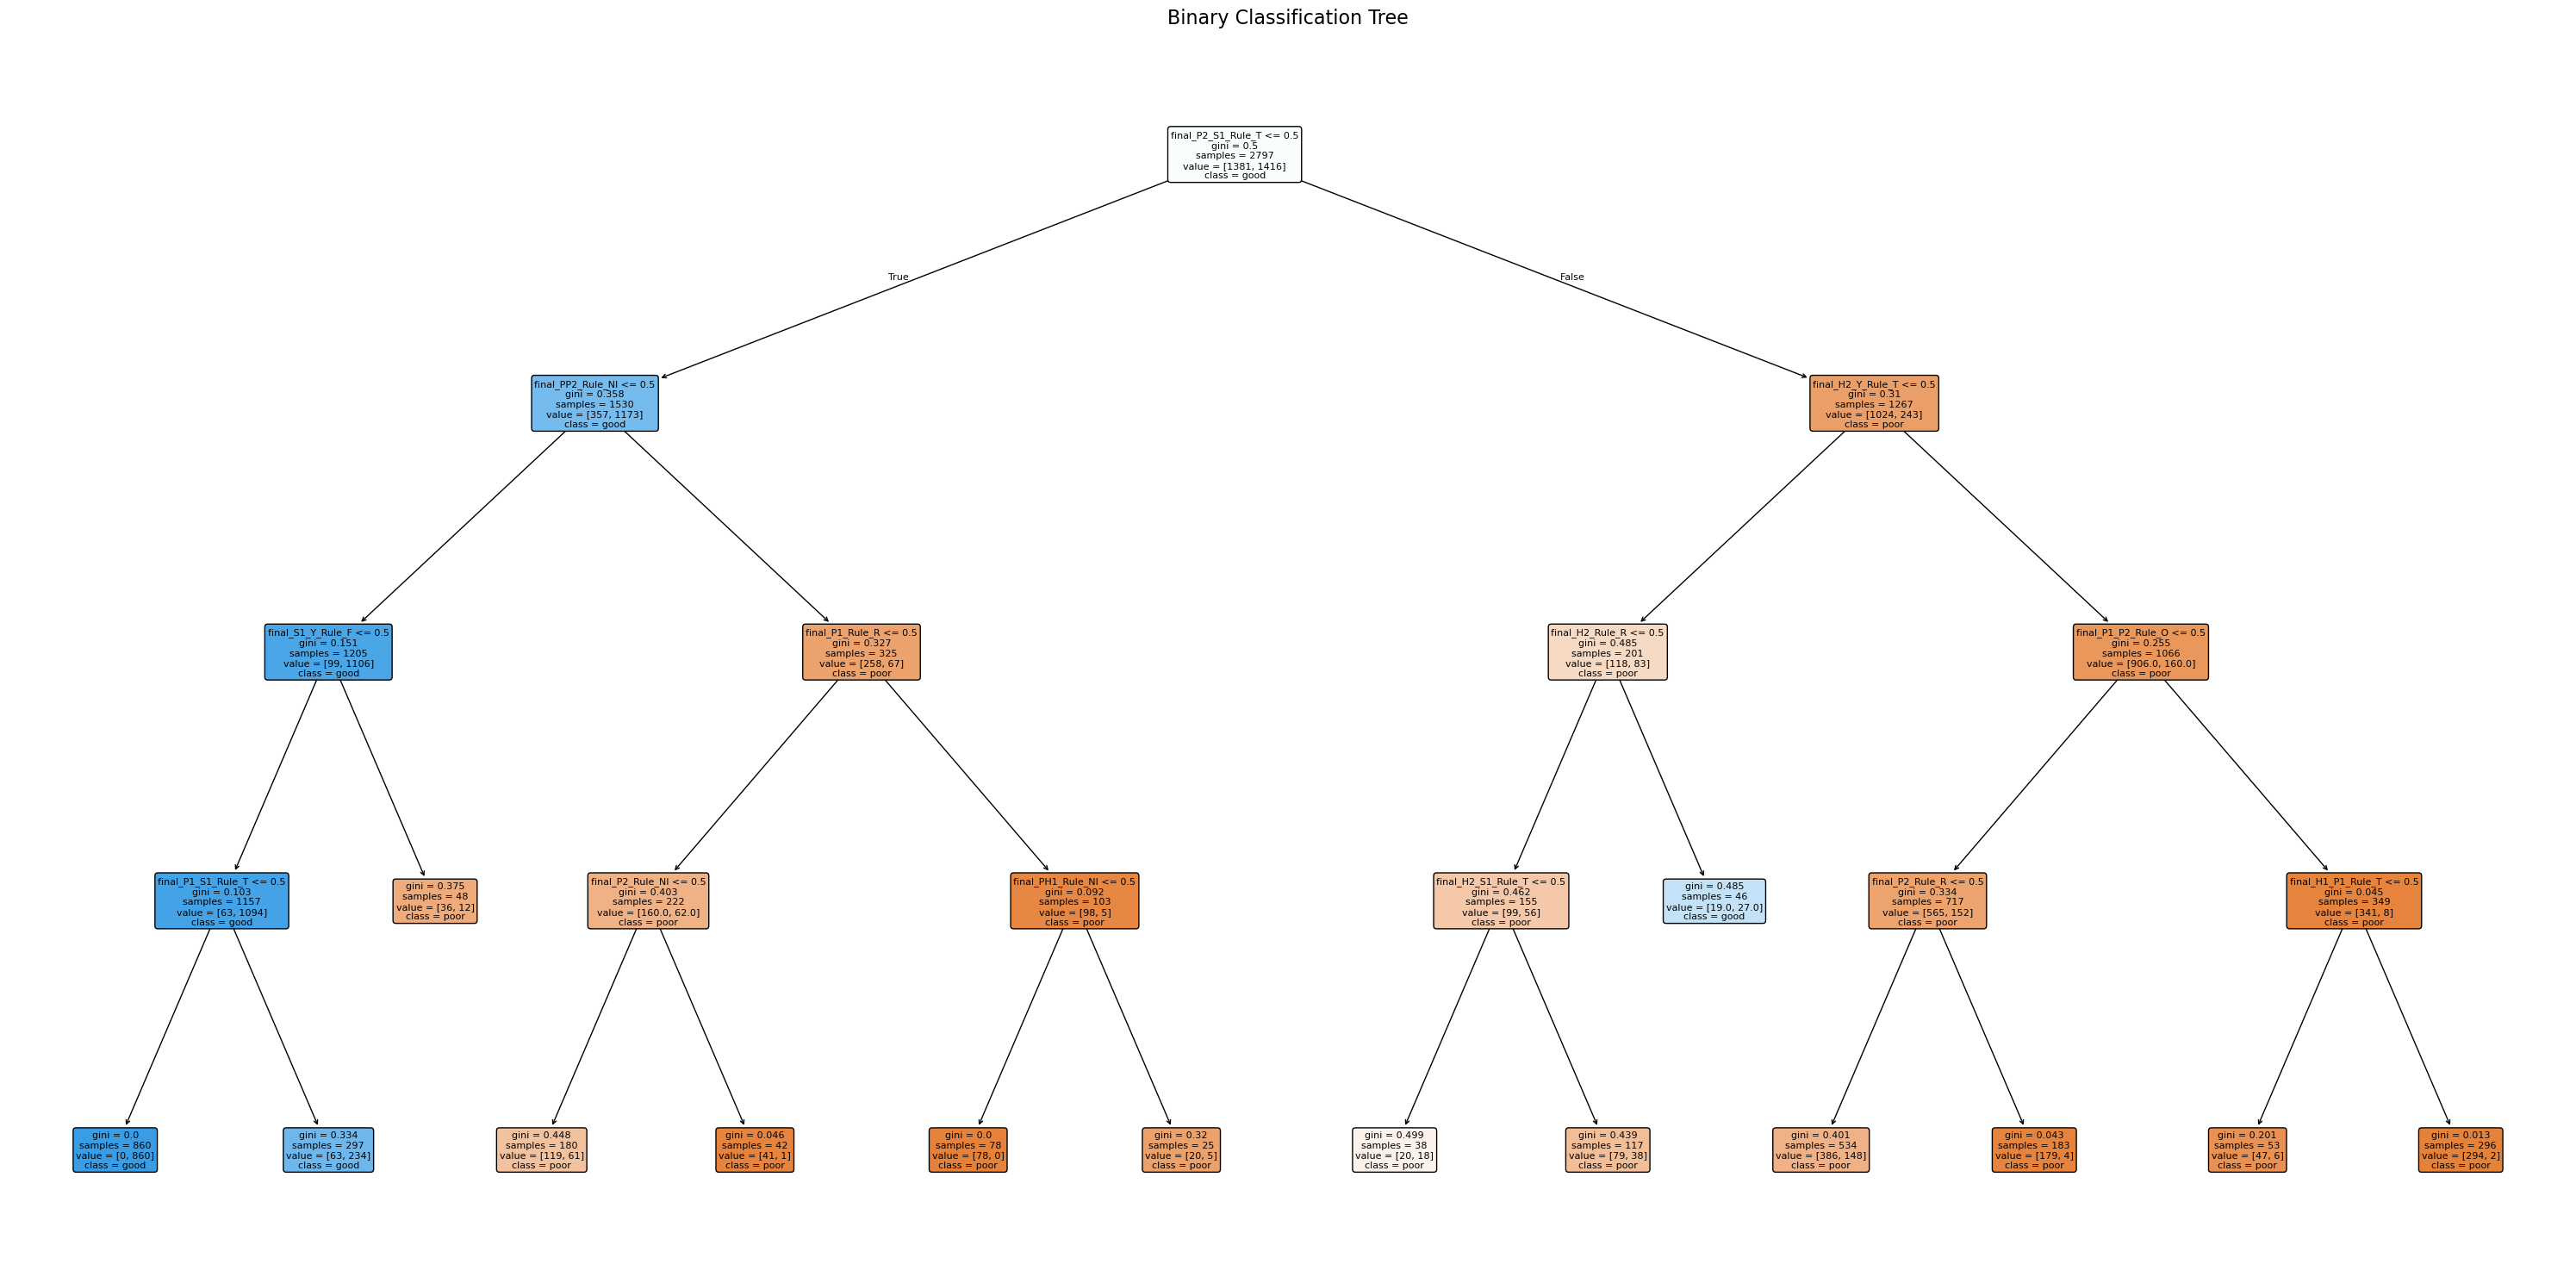

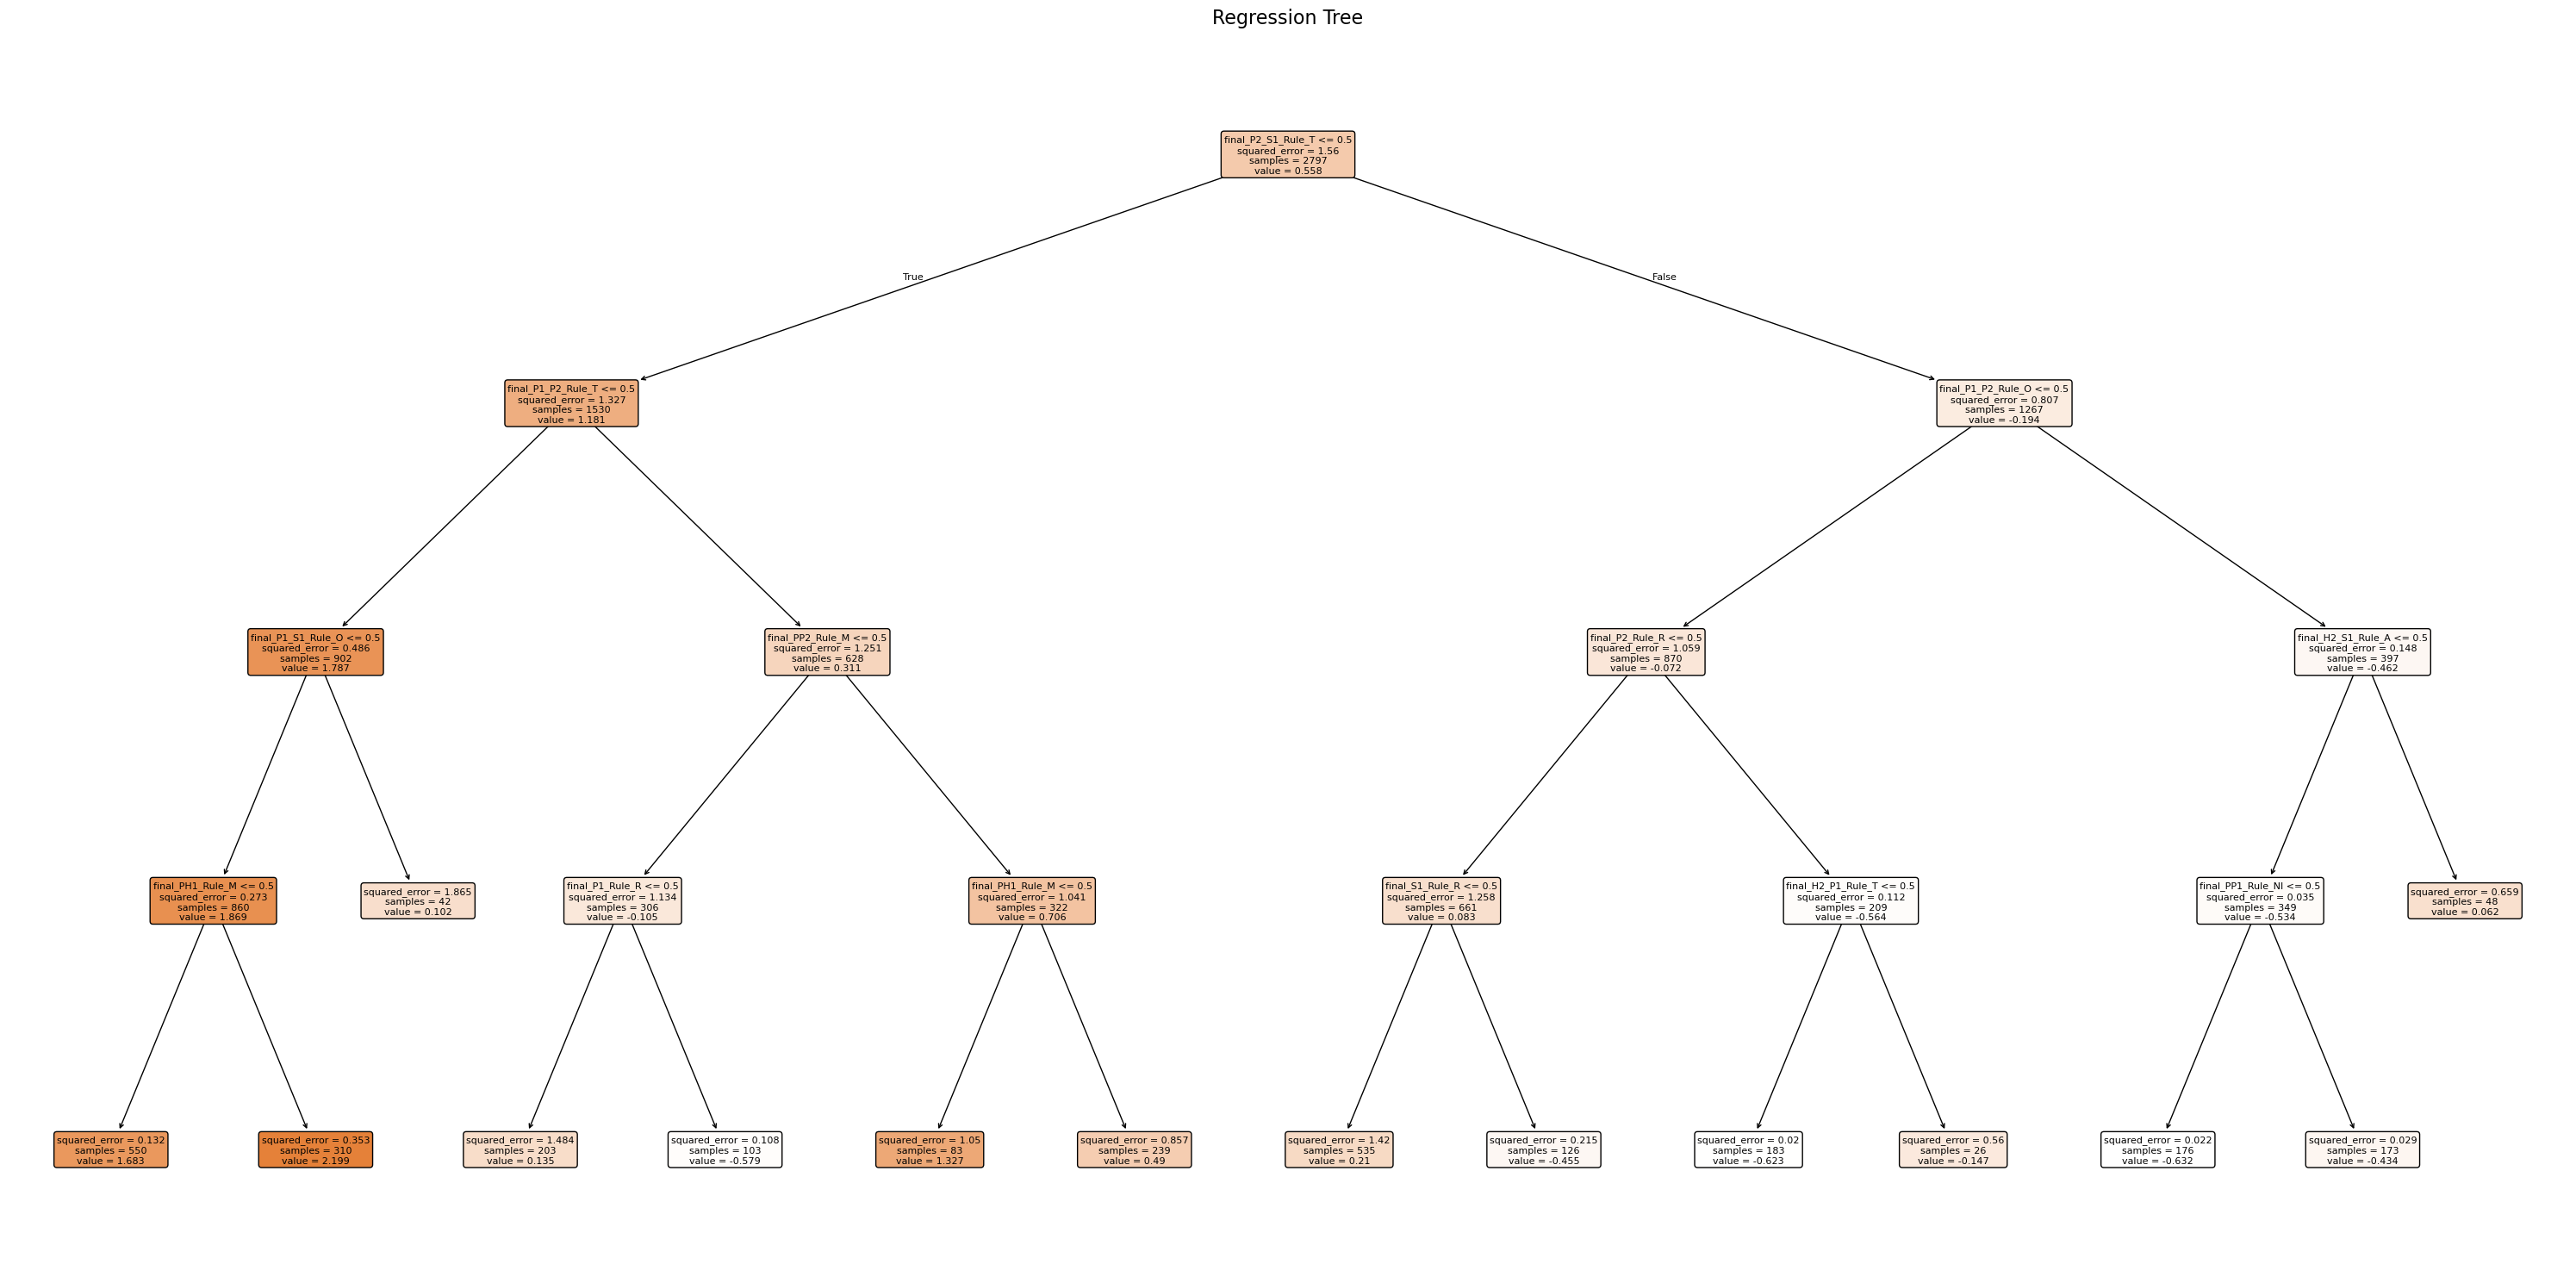

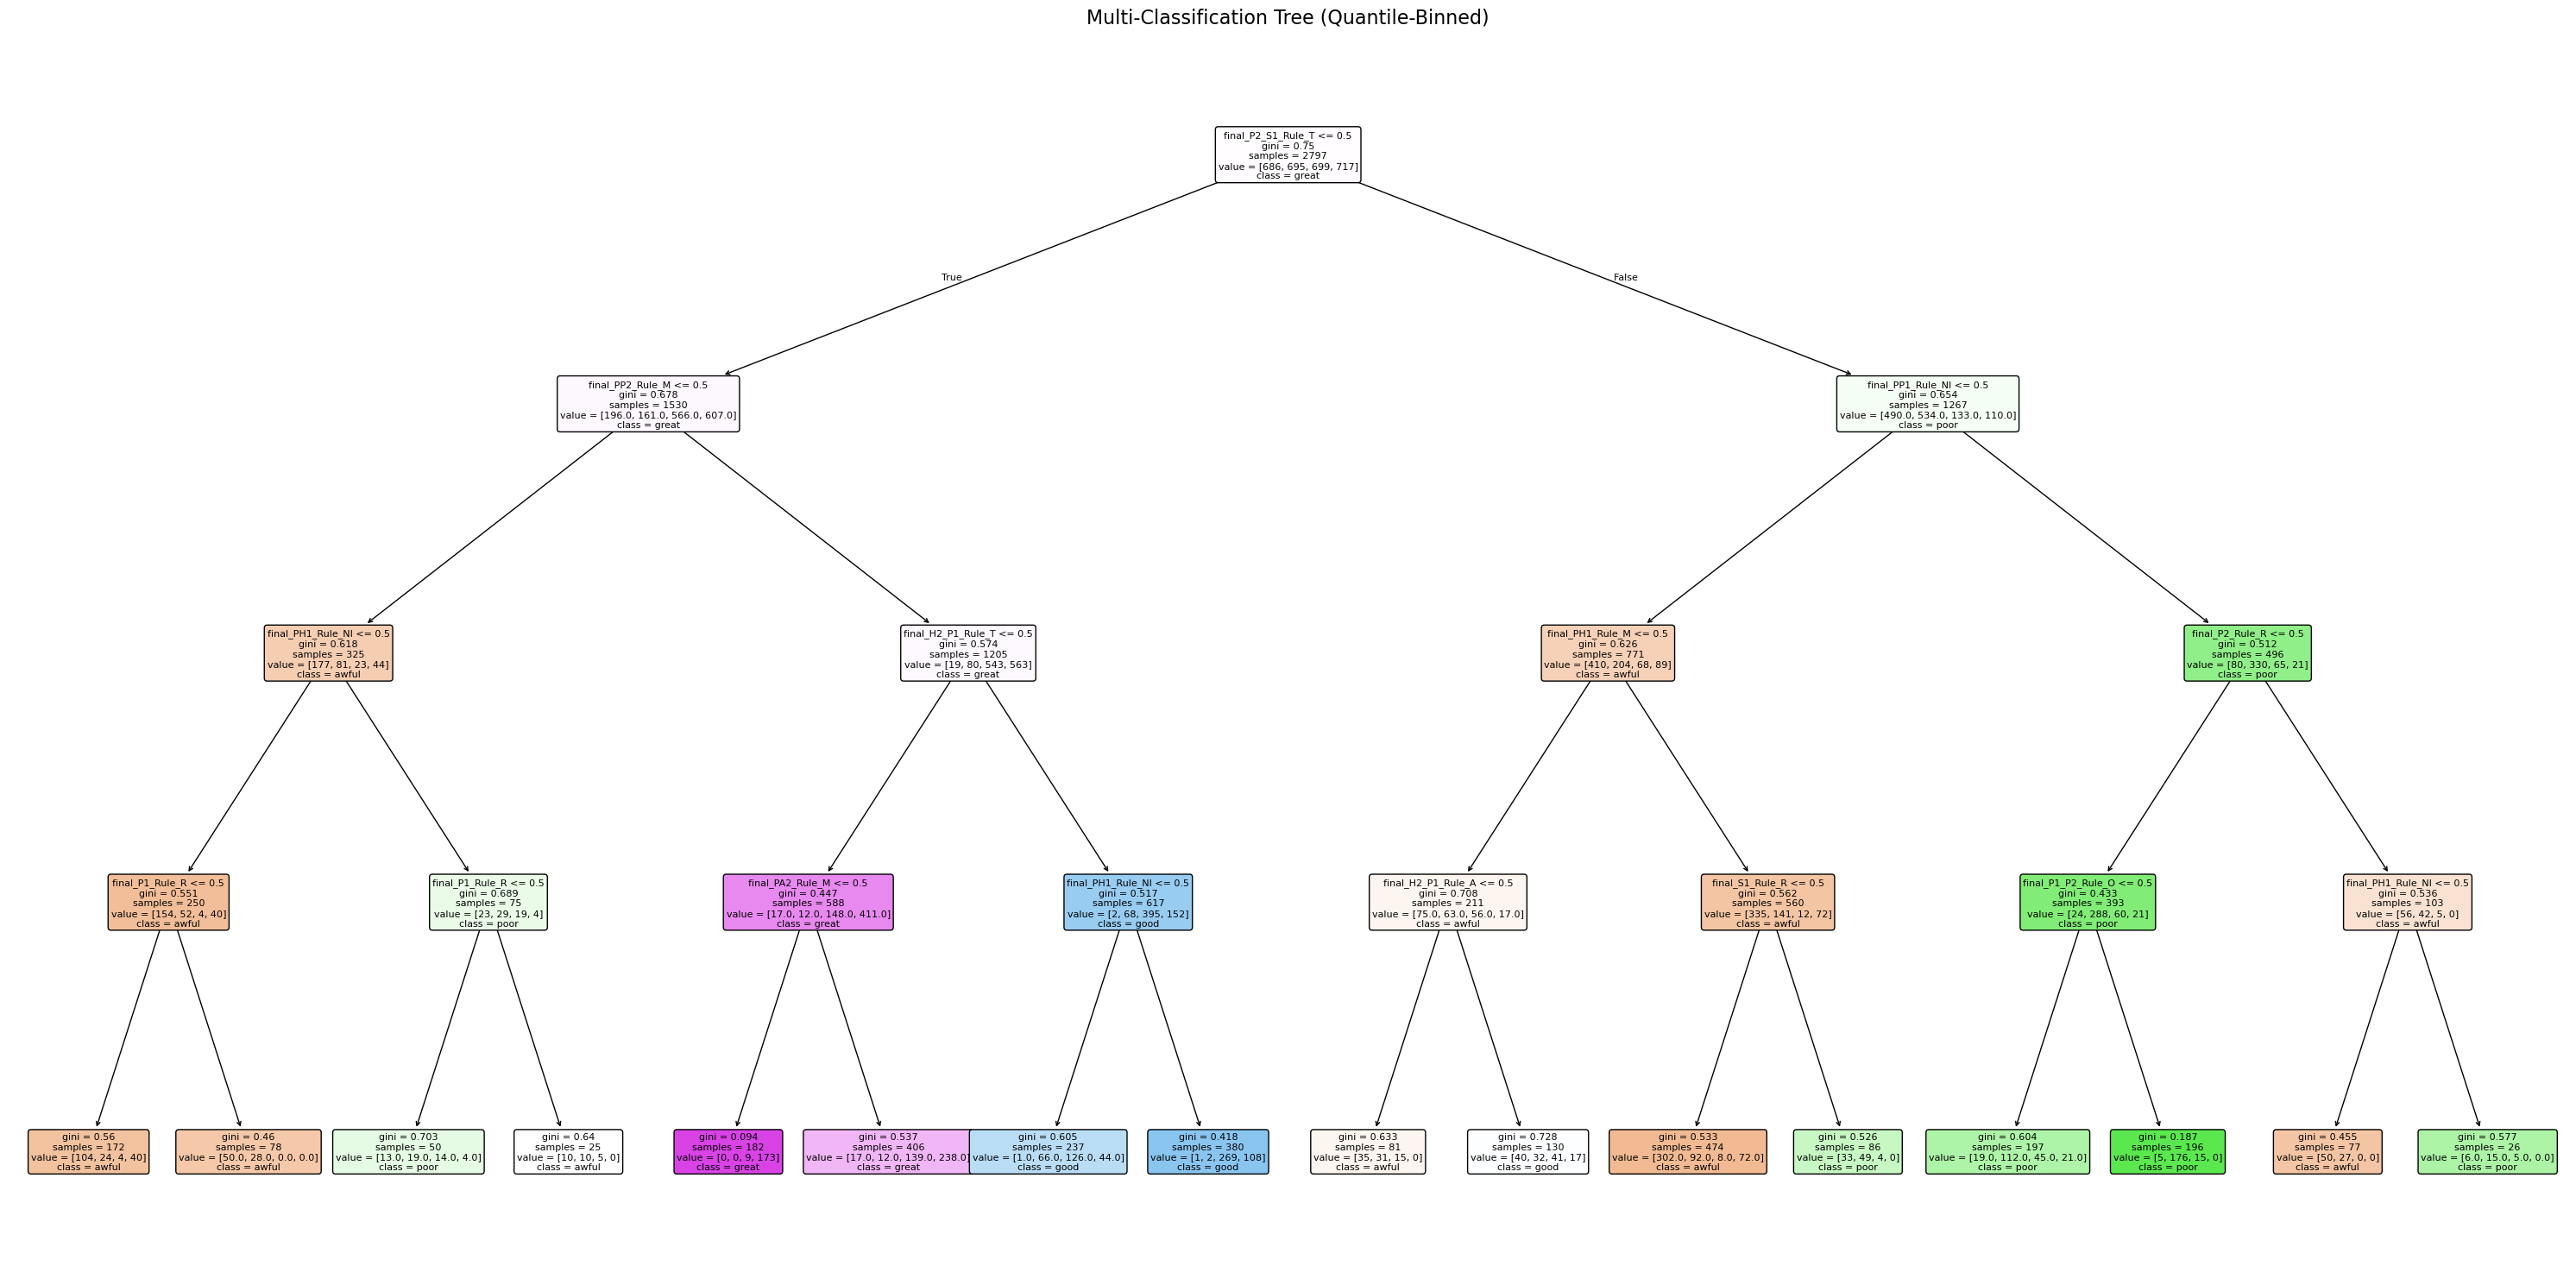

In [51]:
# Binary Classification Tree
fig1, ax1 = plt.subplots(figsize=(30, 15))
tree.plot_tree(bc_tree, feature_names=feature_names, class_names=["poor", "good"], filled=True, rounded=True, fontsize=8, ax=ax1)
ax1.set_title("Binary Classification Tree", fontsize=16)
plt.tight_layout()
plt.savefig("binary_classification_tree.png", dpi=150, bbox_inches='tight')
plt.show()

# Regression Tree
fig2, ax2 = plt.subplots(figsize=(30, 15))
tree.plot_tree(reg_tree, feature_names=feature_names, filled=True, rounded=True, fontsize=8, ax=ax2)
ax2.set_title("Regression Tree", fontsize=16)
plt.tight_layout()
plt.savefig("regression_tree.png", dpi=150, bbox_inches='tight')
plt.show()

# Multi-Classification Tree
fig3, ax3 = plt.subplots(figsize=(30, 15))
tree.plot_tree(mc_tree, feature_names=feature_names, class_names=["awful", "poor", "good", "great"], filled=True, rounded=True, fontsize=8, ax=ax3)
ax3.set_title("Multi-Classification Tree (Quantile-Binned)", fontsize=16)
plt.tight_layout()
plt.savefig("multi_classification_tree.png", dpi=150, bbox_inches='tight')
plt.show()

## Save Trees

In [64]:
fig1.savefig("binary_classification_tree.png", dpi=150, bbox_inches='tight')
fig2.savefig("regression_tree.png", dpi=150, bbox_inches='tight')
fig3.savefig("multi_classification_tree.png", dpi=150, bbox_inches='tight')
print("Saved: binary_classification_tree.png, regression_tree.png, multi_classification_tree.png")

Saved: binary_classification_tree.png, regression_tree.png, multi_classification_tree.png


## Save Purity Metrics and DesignToRule DF to CSV

In [60]:
purity_metrics_df.to_csv("purity_metrics.csv")
designToRule_df.to_csv("designToRule.csv")
print("Saved purity_metrics.csv and designToRule.csv")

Saved purity_metrics.csv and designToRule.csv


# Deliverables

In [66]:
print("Top 10 rules by impact:")
print(purity_metrics_df.sort_values("impact", ascending=False).head(10)[["ruleSpaceID", "impact", "goodnessPercent", "poorEliminationPercent"]])

Top 10 rules by impact:
                           ruleSpaceID impact goodnessPercent  \
final_P2_S1_Rule_T  final_P2_S1_Rule_T     56              82   
final_P2_Y_Rule_F    final_P2_Y_Rule_F     51              87   
final_P2_Y_Rule_A    final_P2_Y_Rule_A     51              87   
final_P2_S1_Rule_F  final_P2_S1_Rule_F     51              87   
final_P2_S1_Rule_A  final_P2_S1_Rule_A     51              87   
final_P2_Rule_NI      final_P2_Rule_NI     51              87   
final_P2_Y_Rule_O    final_P2_Y_Rule_O     51              87   
final_PP2_Rule_NI    final_PP2_Rule_NI     38              89   
final_P1_S1_Rule_T  final_P1_S1_Rule_T     35              71   
final_PH1_Rule_M      final_PH1_Rule_M     32              53   

                   poorEliminationPercent  
final_P2_S1_Rule_T                     80  
final_P2_Y_Rule_F                      84  
final_P2_Y_Rule_A                      84  
final_P2_S1_Rule_F                     84  
final_P2_S1_Rule_A                     8

### 1. How many rules did you use? Why did you choose those rules?

We used 239 rules generated across rule types R, B, T, O, I, F, A, M, NI, S, and E with a design length of 8 (matching our 8-part genetic circuits). We chose a variety of rule types to capture different structural constraints: R (no repeat) captures part uniqueness, B (before) captures ordering, T (together) captures co-occurrence, O (not together) captures exclusion, I/F/A capture adjacency and positioning, M/NI (must include/not include) captures presence/absence, and S/E (start/end) captures positional constraints. This diversity ensures the decision trees have a rich feature set to distinguish good from poor designs.

### 2. What are we learning from each type of tree?

- **Binary Classification Tree**: Learns which rules best separate "good" designs (above median score) from "poor" designs (below median). Provides a simple yes/no prediction of design quality.
- **Regression Tree**: Learns which rules predict the actual numeric Cello score. Leaf nodes give average score values, allowing us to estimate how well a design will perform quantitatively.
- **Multi-Classification Tree**: Learns which rules distinguish between four quality tiers (awful, poor, good, great based on quartiles). Provides more granular insight into design quality than binary classification.

### 3. What are some interesting insights you noticed about some of the rules?

Several rules involving part P2 dominated the top impact scores. The highest-impact rule was P2_S1_Rule_T (impact=56), which requires P2 and S1 to appear together in the same design. This suggests co-occurrence of the PhlF repressor variant P2 with the SrpR repressor S1 is a strong predictor of circuit quality. Rules involving P2 and Y (the output reporter) also scored highly (impact=51), indicating that certain repressor-reporter pairings are important for good circuit performance. Interestingly, the "Not Include P2" rule (final_P2_Rule_NI) also had high impact (51), meaning designs that exclude P2 tend to cluster strongly as either good or poor. The "Not Include PP2" rule (impact=38) suggests that certain promoters negatively affect circuit performance. Overall, the most informative rules involve specific part pairings rather than simple presence/absence constraints.

### 4. If you were to experimentally validate five of these rules, which would you choose? Why?

1. **P2_S1_Rule_T** (impact=56) — Highest impact; tests whether P2 and S1 co-occurrence drives circuit quality.
2. **P2_Y_Rule_F** (impact=51) — Tests whether P2 directly before Y improves output expression.
3. **P2_Y_Rule_A** (impact=51) — Tests whether P2 directly after Y matters for circuit function.
4. **PP2_Rule_NI** (impact=38) — Tests whether excluding promoter PP2 improves performance.
5. **P1_S1_Rule_T** (impact=35) — Tests whether P1 and S1 co-occurrence is also beneficial, providing a comparison to the P2_S1 pairing.

These five rules were chosen because they have the highest impact scores, meaning they best distinguish good from poor designs. Validating them experimentally would confirm whether these compositional constraints are genuine biological design principles or artifacts of the Cello simulation model.